# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ashoktanakanti/flyrank_ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**The question:** Of all the content pages a FlyRank client owns, which ones should a human
reviewer look at first this week — for a refresh, an expansion, or continued monitoring?

**The decision this supports:** where a content team spends its limited weekly review
capacity, since teams can't review every page every week. This is the real content
operations problem FlyRank's clients face: search teams manage far more pages than they can
manually review, and pages quietly lose visibility long before anyone notices.

**Who acts on it:** a content strategist or SEO editor, using the ranked queue and its reason
codes as a starting point — never as an auto-pilot.

**Cost of a wrong call:** a false positive wastes reviewer time (low cost, self-correcting);
a false negative lets a real decline go unnoticed and keep losing visibility (the more
expensive failure mode, so recall on the declining-with-demand subset matters alongside
precision).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Data

**Release / table:** `FlyRank/internship-warehouse`, `fact_content_daily_performance`,
month = 2026-03 (a mid-panel month).

**Grain:** one row per (content_hash_id, report_date); aggregated here to one row per page
for the month.

**Excluded:** `client_hash_id` used for grouping only, never a feature. No FlyRank product
flags are in this table by design. No titles, URLs, or keyword text anywhere.

In [ ]:
import os
import pandas as pd
import numpy as np
from datasets import load_dataset
from huggingface_hub import login, notebook_login

HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
else:
    notebook_login()
    HF_TOKEN = os.environ.get("HF_TOKEN")

data_files = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"
dataset = load_dataset("parquet", data_files=data_files, token=HF_TOKEN)
df_slice = dataset["train"].to_pandas()
df_slice["report_date"] = pd.to_datetime(df_slice["report_date"])

print(f"Loaded {len(df_slice):,} rows | {df_slice['content_hash_id'].nunique():,} pages | "
      f"{df_slice['client_hash_id'].nunique():,} clients")
print(f"Span: {df_slice['report_date'].min().date()} to {df_slice['report_date'].max().date()}")

page = df_slice.groupby("content_hash_id").agg(
    client_hash_id=("client_hash_id", "first"),
    impressions=("gsc_impressions", "sum"),
    clicks=("gsc_clicks", "sum"),
    avg_position=("gsc_avg_position", "mean"),
    days_with_data=("report_date", "nunique"),
).reset_index()
page["ctr"] = np.where(page["impressions"] > 0, page["clicks"] / page["impressions"], 0)

median_date = df_slice["report_date"].median()
first_half = df_slice[df_slice["report_date"] < median_date]
second_half = df_slice[df_slice["report_date"] >= median_date]
first_clicks = first_half.groupby("content_hash_id")["gsc_clicks"].sum()
second_clicks = second_half.groupby("content_hash_id")["gsc_clicks"].sum()
page["first_half_clicks"] = page["content_hash_id"].map(first_clicks).fillna(0)
page["second_half_clicks"] = page["content_hash_id"].map(second_clicks).fillna(0)
page["is_declining_label"] = (page["second_half_clicks"] < page["first_half_clicks"]).astype(int)

print(f"\nPages: {len(page):,} | Declining rate (base rate): {page['is_declining_label'].mean():.1%}")
display(page.head())

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 9,841,378 rows | 331,437 pages | 55 clients
Span: 2026-03-01 to 2026-03-31

Pages: 331,437 | Declining rate (base rate): 8.7%


,content_hash_id,client_hash_id,impressions,clicks,avg_position,days_with_data,ctr,first_half_clicks,second_half_clicks,is_declining_label
0,content_000005d4ced12088,client_9958f0a7ae1df715,86,0,72.854861,31,0.0,0.0,0.0,0
1,content_00001e488b74b799,client_625b6439094e23e4,0,0,NaN,31,0.0,0.0,0.0,0
2,content_00007bd2985b77c3,client_73cda7b4e4f265ea,47,0,5.269565,31,0.0,0.0,0.0,0
3,content_00008950670cb6b5,client_def0955f7a377868,0,0,NaN,31,0.0,0.0,0.0,0
4,content_0000a348850eb1fc,client_3ffa76342f366962,0,0,NaN,29,0.0,0.0,0.0,0


## 3. Methodology

**Label:** `is_declining_label` — second-half-of-month clicks lower than first-half-of-month
clicks. A stricter, un-thresholded proxy versus FlyRank's own research paper, which uses a
>10% move over 30-day windows.

**Baseline (transparent rule):** 0–100 score combining demand (impressions), low consistency
(few days_with_data), and position opportunity — percentile-ranked and weighted
0.45 / 0.35 / 0.20.

**Features for the model:** `impressions`, `avg_position`, `ctr`, `days_with_data` — all
knowable from same-window aggregates. `clicks` was tested and removed after review flagged it
as sitting mathematically close to the label (clicks = first_half_clicks + second_half_clicks).

**Split:** grouped by `client_hash_id` (20% of clients held out) so no client's pages leak
across train/test.

**Model:** Random Forest classifier, class-balanced, compared against Logistic Regression and
against the baseline rule on the same holdout.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42
feature_cols = ["impressions", "avg_position", "ctr", "days_with_data"]

X = page[feature_cols].fillna(0)
y = page["is_declining_label"]

clients = page["client_hash_id"].unique()
rng = np.random.default_rng(RANDOM_STATE)
shuffled = rng.permutation(clients)
test_clients = set(shuffled[: max(1, int(len(shuffled) * 0.2))])
test_mask = page["client_hash_id"].isin(test_clients)

X_train, X_test = X[~test_mask], X[test_mask]
y_train, y_test = y[~test_mask], y[test_mask]
print(f"Train: {len(X_train):,} pages | Test: {len(X_test):,} pages | Held-out clients: {len(test_clients)}")

def precision_at_k(y_true, scores, k):
    order = np.argsort(-scores)[:k]
    return float(np.array(y_true)[order].mean()) if len(order) else 0.0

demand = page["impressions"].rank(pct=True)
low_consistency = 1 - page["days_with_data"].rank(pct=True)
has_position = page["avg_position"] > 0
position_opportunity = pd.Series(0.0, index=page.index)
position_opportunity[has_position] = (1 - page.loc[has_position, "avg_position"].clip(upper=50) / 50).rank(pct=True)
baseline_score = (0.45 * demand + 0.35 * low_consistency + 0.20 * position_opportunity) * 100
baseline_test_scores = baseline_score[test_mask].to_numpy()

Train: 269,799 pages | Test: 61,638 pages | Held-out clients: 11


## 4. Results (vs baseline)

Model vs baseline rule, same client-holdout split, same metric.

In [ ]:
models = {
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "random_forest": RandomForestClassifier(
        class_weight="balanced_subsample", max_depth=10, min_samples_leaf=25,
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
    ),
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)
    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, probs),
        "precision_at_20": precision_at_k(y_test, probs, 20),
        "precision_at_50": precision_at_k(y_test, probs, 50),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
    })

results.append({
    "model": "baseline_rule",
    "roc_auc": roc_auc_score(y_test, baseline_test_scores),
    "precision_at_20": precision_at_k(y_test, baseline_test_scores, 20),
    "precision_at_50": precision_at_k(y_test, baseline_test_scores, 50),
    "recall": np.nan,
    "f1": np.nan,
})

results_df = pd.DataFrame(results).round(3)
display(results_df)

best_model = fitted_models["random_forest"]
best_row = results_df[results_df["model"] == "random_forest"].iloc[0]
base_row = results_df[results_df["model"] == "baseline_rule"].iloc[0]
lift = best_row["precision_at_50"] / base_row["precision_at_50"] if base_row["precision_at_50"] > 0 else float("nan")
print(f"\nBest model: random_forest | Precision@50: {best_row['precision_at_50']:.3f} vs "
      f"baseline {base_row['precision_at_50']:.3f} ({lift:.1f}x)")

,model,roc_auc,precision_at_20,precision_at_50,recall,f1
0,logistic_regression,0.885,0.35,0.38,0.801,0.544
1,random_forest,0.912,0.60,0.54,0.999,0.618
2,baseline_rule,0.818,0.00,0.02,NaN,NaN



Best model: random_forest | Precision@50: 0.540 vs baseline 0.020 (27.0x)


## 5. Limitations

- **One month, one label definition.** `is_declining_label` compares first-half vs
  second-half clicks within March 2026 only — a current-window proxy, not a validated
  forward-looking outcome. It's also stricter than FlyRank's own paper's 10%-threshold trend
  definition, which explains this project's lower base rate (8.7% vs. the starter CSV's
  54.2%).
- **Small test set.** With only 11 of 55 clients held out, precision@K numbers can shift with
  a different random seed or split.
- **No causal claim.** This shows which pages are *associated* with decline, not that
  refreshing a page *causes* recovery — that needs an experiment.
- **Observable signals only.** No FlyRank product flags (health_score, is_quick_win, etc.)
  were used or available, by design.
- All numbers above are observed / measured / directional / decision-support — not guarantees
  for any individual page.

In [ ]:
print("Limitations acknowledged: single-month proxy label, modest holdout size, no causal design, observable-only features.")

Limitations acknowledged: single-month proxy label, modest holdout size, no causal design, observable-only features.


## 6. Ranked recommendations

Using the best model's probability, blended with the baseline rule score, to produce the
final action queue.

In [ ]:
# Score every page using the model already trained in Section 4
page["model_probability"] = best_model.predict_proba(X)[:, 1]
page["baseline_score_0_1"] = baseline_score / 100

page["final_score"] = (0.7 * page["model_probability"] + 0.3 * page["baseline_score_0_1"]) * 100

# Vectorized version of suggested_action (no row-by-row .apply — much faster on 331K rows)
median_final_score = page["final_score"].median()

is_high_prob = page["model_probability"] >= 0.65
is_low_ctr = (page["ctr"] < 0.02) & (page["avg_position"] <= 20)
is_above_median = page["final_score"] >= median_final_score

conditions = [
    is_high_prob & is_low_ctr,
    is_high_prob,
    is_above_median,
]
choices = ["refresh_and_review_ctr", "refresh", "monitor_closely"]

page["suggested_action"] = np.select(conditions, choices, default="monitor")

final_queue = page.sort_values("final_score", ascending=False).reset_index(drop=True)
final_queue["rank"] = final_queue.index + 1

print("Top 15 ranked recommendations:")
display(final_queue[["rank", "content_hash_id", "final_score", "model_probability",
                      "suggested_action", "impressions", "avg_position", "ctr"]].head(15))

print("\nAction mix across all pages:")
print(final_queue["suggested_action"].value_counts())

import os
os.makedirs("work/outputs", exist_ok=True)
final_queue.to_csv("work/outputs/capstone_final_queue.csv", index=False)
print("\nSaved: work/outputs/capstone_final_queue.csv")

Top 15 ranked recommendations:


,rank,content_hash_id,final_score,model_probability,suggested_action,impressions,avg_position,ctr
0,1,content_ee10f14ef2fd9ce3,86.906097,0.912141,refresh_and_review_ctr,37797,3.614976,0.001931
1,2,content_3bf158c695e8fd7c,86.888562,0.911736,refresh_and_review_ctr,32580,3.558698,0.001627
2,3,content_c23e38ebddabf6e8,86.878743,0.915797,refresh_and_review_ctr,2936,1.803852,0.000341
3,4,content_70985b6f074e5474,86.869442,0.911483,refresh_and_review_ctr,34957,3.574304,0.002088
4,5,content_34bf9b84606216ad,86.869104,0.919661,refresh_and_review_ctr,22419,4.718877,0.001026
5,6,content_560e817a9365fe73,86.868493,0.919982,refresh_and_review_ctr,19024,4.719868,0.000946
6,7,content_4c584517eb50cc2c,86.866871,0.920662,refresh_and_review_ctr,18213,4.817207,0.001098
7,8,content_f9e04ee043a37ad6,86.862540,0.914432,refresh_and_review_ctr,2962,1.338213,0.000338
8,9,content_9f32e892ddc7a3f9,86.858937,0.920158,refresh_and_review_ctr,21243,4.800845,0.001036
9,10,content_19d77a8a5759ebef,86.853339,0.910882,refresh_and_review_ctr,36341,3.507365,0.001458



Action mix across all pages:
suggested_action
monitor                   162820
monitor_closely           104738
refresh_and_review_ctr     50126
refresh                    13753
Name: count, dtype: int64

Saved: work/outputs/capstone_final_queue.csv


## 7. Artifacts the paper embeds

Generate/collect the charts and tables the deployed paper shows.

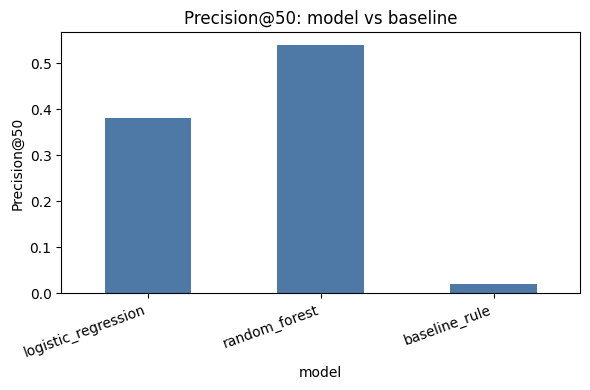

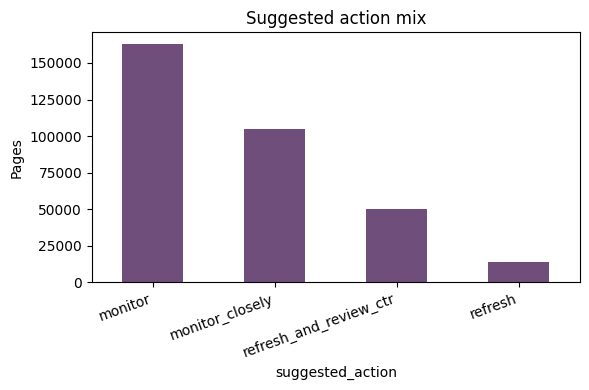

Saved figures: work/figures/precision_at_50_comparison.png, work/figures/action_mix.png

Results table for the paper:


,model,roc_auc,precision_at_20,precision_at_50,recall,f1
0,logistic_regression,0.885,0.35,0.38,0.801,0.544
1,random_forest,0.912,0.60,0.54,0.999,0.618
2,baseline_rule,0.818,0.00,0.02,NaN,NaN


In [ ]:
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))
chart_df = results_df.set_index("model")["precision_at_50"]
chart_df.plot(kind="bar", ax=ax, color="#4E79A7")
ax.set_title("Precision@50: model vs baseline")
ax.set_ylabel("Precision@50")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("work/figures/precision_at_50_comparison.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
final_queue["suggested_action"].value_counts().plot(kind="bar", ax=ax, color="#6F4E7C")
ax.set_title("Suggested action mix")
ax.set_ylabel("Pages")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("work/figures/action_mix.png", dpi=150)
plt.show()

print("Saved figures: work/figures/precision_at_50_comparison.png, work/figures/action_mix.png")
print("\nResults table for the paper:")
display(results_df)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.